# **Задание №1. Использование глубокой сверточной нейронной сети для классификации предметов одежды на примере датасета Fashion MNIST**


**В качестве интерфейса для работы с моделями используйте [Streamlit](https://colab.research.google.com/drive/1PUvx9rGgAYSb2dZfGbzjfqRK86CLzsko#scrollTo=kSbmm9EjH5Uz)**

[Техническая документация по датасету](https://www.kaggle.com/datasets/zalando-research/fashionmnist)

## 1.1. Устанавливаем необходимые зависимости

In [1]:
from keras.datasets import fashion_mnist # импорт исходного датасета
from keras.models import Sequential
from keras.utils import to_categorical
from keras.layers import Conv2D, MaxPooling2D, Dense, Flatten

from keras.optimizers import Adam, SGD
import matplotlib.pyplot as plt
import numpy as np
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau


## 1.2. Разделяем данные на обучающую и тестовую выборку

In [2]:
(trainX, trainy), (testX, testy) = fashion_mnist.load_data()

print('Train: X = ', trainX.shape)
print('Test: X = ', testX.shape)

y_train_cat = to_categorical(trainy, 10)
y_test_cat = to_categorical(testy, 10)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Train: X =  (60000, 28, 28)
Test: X =  (10000, 28, 28)


## 1.3. Визуализируем часть данных из датасета

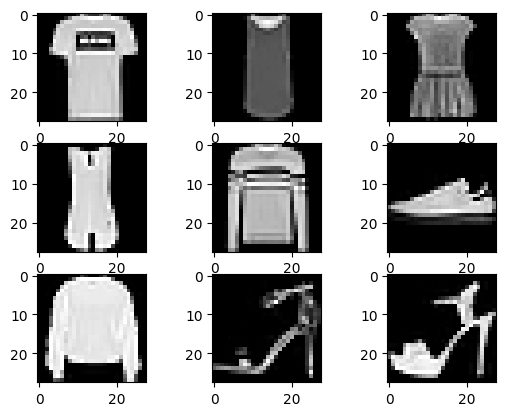

In [3]:
for i in range(1, 10):
    plt.subplot(3, 3, i)
    plt.imshow(trainX[i], cmap=plt.get_cmap('gray'))

plt.show()

## 1.4. Создаём архитектуру нейронной сети и компилируем модель

In [4]:
model = Sequential([
    # Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(28, 28, 1)),
    Conv2D(64, (3,3), padding='same', activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2), strides=2),
    Conv2D(32, (3,3), padding='same', activation='relu'),
    MaxPooling2D((2, 2), strides=2),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10,  activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1568)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       200,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 221,226 (864.16 KB)

 Trainable params: 221,226 (864.16 KB)

 Non-trainable params: 0 (0.00 B)

## 1.5. Обучаем модель

In [5]:
EPOCH = 5

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

checkpoint = ModelCheckpoint(
    'best_cnn.h5',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

callbacks = [checkpoint, early_stop, reduce_lr]



his = model.fit(
    trainX, y_train_cat,
    batch_size=32,
    epochs=EPOCH,
    validation_split=0.2,
    callbacks=callbacks
)


model.evaluate(testX, y_test_cat) # метод evaluate() предназначен для оценки уже обученной модели с использованием данных проверки
                                   #(или тестирования) и соответствующих меток. Возвращает значение потерь и значения показателей для модели.

Epoch 1/5
1493/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7892 - loss: 0.9578
Epoch 1: val_accuracy improved from -inf to 0.87692, saving model to best_cnn.h5


1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.7894 - loss: 0.9553 - val_accuracy: 0.8769 - val_loss: 0.3382 - learning_rate: 0.0010
Epoch 2/5
1499/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8894 - loss: 0.3023
Epoch 2: val_accuracy improved from 0.87692 to 0.88925, saving model to best_cnn.h5


1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8894 - loss: 0.3023 - val_accuracy: 0.8892 - val_loss: 0.3072 - learning_rate: 0.0010
Epoch 3/5
1485/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9022 - loss: 0.2655
Epoch 3: val_accuracy did not improve from 0.88925
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9022 - loss: 0.2655 - val_accuracy: 0.8882 - val_loss: 0.3131 - learning_rate: 0.0010
Epoch 4/5
1493/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9092 - loss: 0.2409
Epoch 4: val_accuracy improved from 0.88925 to 0.89683, saving model to best_cnn.h5


1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9092 - loss: 0.2409 - val_accuracy: 0.8968 - val_loss: 0.2797 - learning_rate: 0.0010
Epoch 5/5
1488/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9212 - loss: 0.2115
Epoch 5: val_accuracy improved from 0.89683 to 0.89983, saving model to best_cnn.h5


1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9212 - loss: 0.2115 - val_accuracy: 0.8998 - val_loss: 0.2909 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 4.
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8886 - loss: 0.3037


[0.30003058910369873, 0.8916000127792358]

## 1.6. Анализируем обученную модель. Строим график (графики) обучения

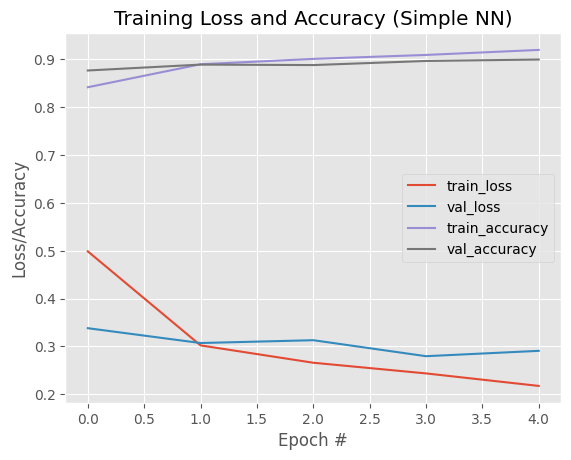

In [6]:
N = np.arange(0, EPOCH)
plt.style.use("ggplot")
plt.figure()
plt.plot(N, his.history["loss"], label="train_loss")
plt.plot(N, his.history["val_loss"], label="val_loss")
plt.plot(N, his.history["accuracy"], label="train_accuracy")
plt.plot(N, his.history["val_accuracy"], label="val_accuracy")
plt.title("Training Loss and Accuracy (Simple NN)")
plt.xlabel("Epoch #")
plt.ylabel("Loss/Accuracy")
plt.legend()

## 1.7. Загружаем свои изображения. С помощью функции predict() получаем предсказание нейронной сети



> Требуется получить предсказания минимум по 5 изображениям, каждое из которых относится к разному классу. Не забудьте добавить метки к каждому классу (для этого можно просто создать список строк, каждая из которых будет соответствовать классу с определенным индексом см. [тех.док.](https://www.kaggle.com/datasets/zalando-research/fashionmnist)). Процент уверенности нейронной сети в своём предсказании выводить обязательно.



In [7]:
# Скачиваем архив с набором данных
!curl -L -o clothes_dataset.zip \
  https://www.kaggle.com/api/v1/datasets/download/ryanbadai/clothes-dataset


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 1405M  100 1405M    0     0  20.1M      0  0:01:09  0:01:09 --:--:-- 21.3M


In [8]:
%%capture
# Распаковываем архив в папку dataset (%%capture подавляет вывод большого списка файлов)
!unzip clothes_dataset.zip -d new_dataset

In [9]:
import os
from glob import glob

base_dir = '/content/new_dataset/Clothes_Dataset'

kaggle_classes = ['Polo', 'Jeans', 'Hoodie', 'Kemeja', 'Jaket']

image_paths = []
true_labels = []

for cls in kaggle_classes:
    folder = os.path.join(base_dir, cls)
    files = sorted(glob(os.path.join(folder, '*')))
    if not files:
        continue
    image_paths.append(files[0])
    true_labels.append(cls)

len(image_paths), image_paths

(5,
 ['/content/new_dataset/Clothes_Dataset/Polo/001068a8-86c3-4029-a9d9-1e27015e7e64.jpg',
  '/content/new_dataset/Clothes_Dataset/Jeans/08973288-3d8b-4c07-9f2d-ce1392da54be.jpg',
  '/content/new_dataset/Clothes_Dataset/Hoodie/halfzip_hoodie_awk_1697034196_0d90db76_progressive_thumbnail.jpg',
  '/content/new_dataset/Clothes_Dataset/Kemeja/00e745c9-97d9-429d-8c3f-d3db7a2d2991.jpg',
  '/content/new_dataset/Clothes_Dataset/Jaket/jaket_bomber_reborn__audi_hita_1692870832_39a7fd4b_progressive_thumbnail.jpg'])

In [10]:
import numpy as np
from PIL import Image

IMG_SIZE = 28

def preprocess_image(path):
    img = Image.open(path).convert('L')      # в оттенки серого
    img = img.resize((IMG_SIZE, IMG_SIZE))
    arr = np.array(img).astype('float32')
    # arr = arr / 255.0
    arr = 255.0 - arr

    arr = arr.reshape(IMG_SIZE, IMG_SIZE, 1)
    return arr

X_new = np.stack([preprocess_image(p) for p in image_paths], axis=0)
X_new.shape


(5, 28, 28, 1)

In [11]:
class_names = [
    'T-shirt/top',
    'Trouser',
    'Pullover',
    'Dress',
    'Coat',
    'Sandal',
    'Shirt',
    'Sneaker',
    'Bag',
    'Ankle boot'
]

In [12]:
probs = model.predict(X_new)
pred_indices = np.argmax(probs, axis=1)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 528ms/step


In [13]:
for path, true_label, pred_idx in zip(image_paths, true_labels, pred_indices):
    print('Файл:', path)
    print('  Kaggle класс (папка):', true_label)
    print('  Предсказание модели (Fashion-MNIST):', class_names[pred_idx])
    print()


Файл: /content/new_dataset/Clothes_Dataset/Polo/001068a8-86c3-4029-a9d9-1e27015e7e64.jpg
  Kaggle класс (папка): Polo
  Предсказание модели (Fashion-MNIST): Bag

Файл: /content/new_dataset/Clothes_Dataset/Jeans/08973288-3d8b-4c07-9f2d-ce1392da54be.jpg
  Kaggle класс (папка): Jeans
  Предсказание модели (Fashion-MNIST): Trouser

Файл: /content/new_dataset/Clothes_Dataset/Hoodie/halfzip_hoodie_awk_1697034196_0d90db76_progressive_thumbnail.jpg
  Kaggle класс (папка): Hoodie
  Предсказание модели (Fashion-MNIST): Coat

Файл: /content/new_dataset/Clothes_Dataset/Kemeja/00e745c9-97d9-429d-8c3f-d3db7a2d2991.jpg
  Kaggle класс (папка): Kemeja
  Предсказание модели (Fashion-MNIST): Shirt

Файл: /content/new_dataset/Clothes_Dataset/Jaket/jaket_bomber_reborn__audi_hita_1692870832_39a7fd4b_progressive_thumbnail.jpg
  Kaggle класс (папка): Jaket
  Предсказание модели (Fashion-MNIST): Bag



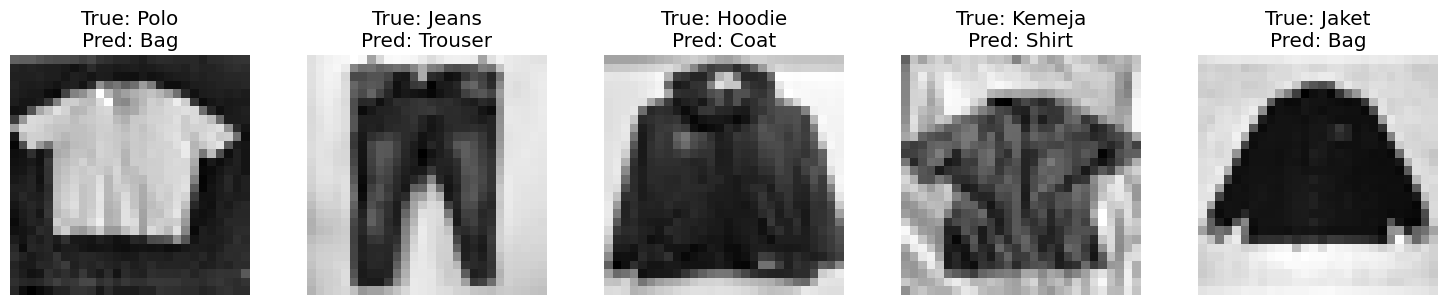

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 3))
for i, (path, true_label, pred_idx) in enumerate(zip(image_paths, true_labels, pred_indices)):
    img = Image.open(path).convert('L').resize((IMG_SIZE, IMG_SIZE))
    plt.subplot(1, len(image_paths), i + 1)
    plt.imshow(img, cmap='gray')
    plt.axis('off')
    plt.title(f'True: {true_label}\nPred: {class_names[pred_idx]}')

plt.tight_layout()
plt.show()


# **Задание №2. Использование глубокой сверточной нейронной сети для классификации изображений по своему датасету**


## 2.1.  Используя датасет, собранный для предыдущей работы, разработайте и обучите **свою** модель глубокой  **сверточной** нейронной сети для классификации изображений







In [15]:
# Ваш код

## 2.2.   Ознакомьтесь с архитектурами сверточных нейронных сетей:

![Текст ссылки](https://velog.velcdn.com/images%2Fimfromk%2Fpost%2Fc04b189d-29cb-405d-93d0-b98dec818517%2Fimage.png)

На основе рассмотренных архитектур, реализуйте (частично повторяя основные паттерны проектирования) и обучите модель сверточной нейронной сети. Укажите архитектуру, которой Вы "вдохновились"

In [16]:
# Ваш код

## 2.3. Сохраните полученные модели

In [17]:
# Ваш код

## 2.4. Загрузите обученную модель из прошлой практической работы


In [18]:
# Ваш код


## 2.5. Сравните между собой точной всех трёх моделей, подавая на вход одинаковые изображения (15 разных изображений). Сравните предсказания каждой из моделей и сделайте выводы

In [19]:
# Ваш код

# **Задание №3. Использование глубокой сверточной нейронной сети для восстановления изображения**

## 3.1. Работа с данными

Будем работать с набором данным `fetch_olivetti_faces` из `sklearn`.

### 3.1.1. Переведите векторы в настоящие изображения из двух размерностей

In [20]:
from sklearn.datasets import fetch_olivetti_faces
from sklearn.model_selection import train_test_split

data, _ = fetch_olivetti_faces(return_X_y=True)
train, test = train_test_split(data, test_size=0.2, random_state=4)

downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to /root/scikit_learn_data


In [21]:
train.shape

(320, 4096)

Сейчас изображение - это вектор, имеющий размерность 4096.

In [22]:
# Ваш код здесь

train = train.reshape((train.shape[0], 64, 64))
test = test.reshape((test.shape[0], 64, 64))

test.shape

(80, 64, 64)

### 3.1.2. Отрисуйте несколько примеров

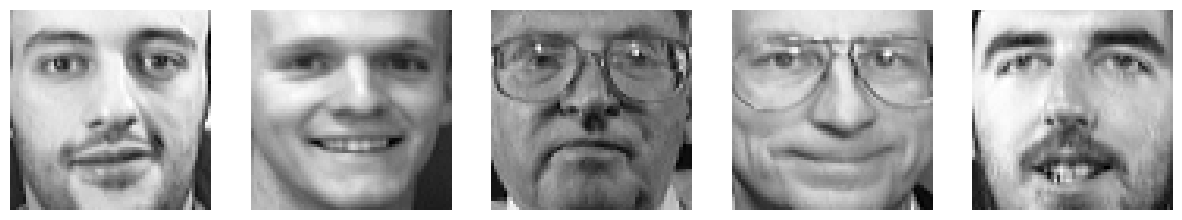

In [23]:
import matplotlib.pyplot as plt


fig, ax = plt.subplots(1, 5, figsize=(15, 10))

for i in range(5):
    ax[i].imshow(train[i], cmap='gray')
    ax[i].axis('off')

Поделим данные на X и y, где X - это верхняя часть лица человека, на этом модель будет обучаться, а y - это нижняя часть лица человека - её будем предсказывать.

In [24]:
n_pixels = train.shape[1]

# Upper half of the faces
X_train = train[:, :(n_pixels + 1) // 2, :]
# Lower half of the faces
y_train = train[:, n_pixels // 2:, :]


X_test = test[:, :(n_pixels + 1) // 2, :]
y_test = test[:, n_pixels // 2:, :]

In [25]:
X_train.shape

(320, 32, 64)

Вот один пример обучающей пары.

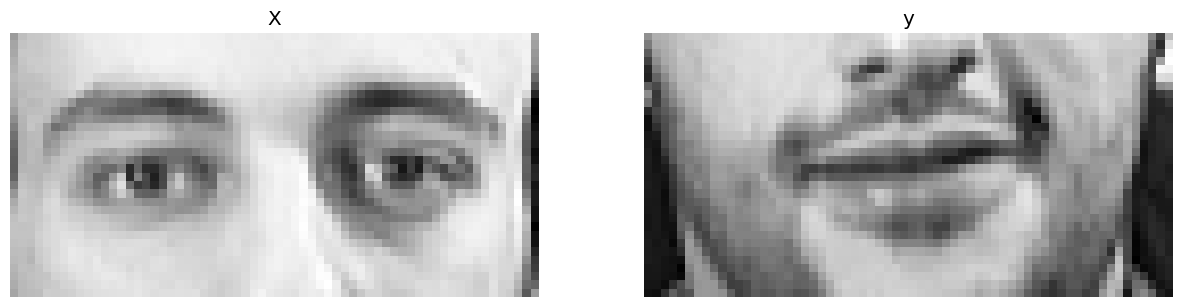

In [26]:
import matplotlib.pyplot as plt

idx = 0

fig, ax = plt.subplots(1, 2, figsize=(15, 8))
ax[0].imshow(X_train[idx], cmap='gray')
ax[0].set_title('X')
ax[1].imshow(y_train[idx], cmap='gray')
ax[1].set_title('y')
ax[0].axis('off')
ax[1].axis('off')

plt.show()

### 3.1.3. Измените размерность y
Остается только изменить размерность y, т.к. сейчас $y$ - картинка 32x64, а выход нейронной сети у нас будет одномерный и равный 32 * 64 = 2048.

In [27]:
y_train_n = y_train.reshape(y_train.shape[0], 32 * 64)
y_test_n = y_test.reshape(y_test.shape[0], 32 * 64)

y_train_n.shape

(320, 2048)

## 3.2. Создайте архитектуру для этой задачи

In [28]:
# Ваш код здесь

## 3.3. Скомпилируйте сеть

Подберите нужную функцию потерь и метрику. Оптимизатор можете использовать 'adam'

In [29]:
# Ваш код здесь

## 3.4. Обучите нейросеть

Выберите нужное количество эпох.


In [30]:
# Ваш код здесь

## 3.5. Сделайте предсказания на тестовых данных

In [31]:
# Ваш код здесь

## 3.6. Посчитайте метрику качества на тестовых данных

In [32]:
# Ваш код здесь

from sklearn.metrics import mean_absolute_error

mean_absolute_error(preds, y_test_n)

NameError: name 'preds' is not defined

## 3.7. Преобразуйте предсказанные векторы в двумерное изображение (поменяйте их размерность)

In [ ]:
# Ваш код здесь

Отрисуйте все предсказания.

In [ ]:
# Пример кода:

n_faces = 5
n_cols = 2
image_shape = (64, 64)
plt.figure(figsize=(3 * n_cols, 3 * n_faces))


for i in range(5):
    true_face = np.vstack((X_test[i], y_test[i]))

    if i:
        sub = plt.subplot(n_faces, n_cols, i * n_cols + 1)
    else:
        sub = plt.subplot(n_faces, n_cols, i * n_cols + 1, title="true faces")

    sub.axis("off")
    sub.imshow(
        true_face.reshape(image_shape), cmap=plt.cm.gray, interpolation="nearest"
    )

    completed_face = np.vstack((X_test[i], pred_test[i]))

    if i:
        sub = plt.subplot(n_faces, n_cols, i * n_cols + 2)

    else:
        sub = plt.subplot(n_faces, n_cols, i * n_cols + 2)

    sub.axis("off")
    sub.imshow(
        completed_face.reshape(image_shape),
        cmap=plt.cm.gray,
        interpolation="nearest",
    )

## 3.8. Предскажите нижнюю половину лица по верхей из загруженной Вами фото (лицо на фото может быть чье угодно)

In [ ]:
# Ваш код здесь